# Task 2 - Decision Trees: Entropy, Over-fitting and Logistic Regression

**Student name:** Nurai Saduakas

**Student ID (last four digits):** 4321




In [ ]:
import sys
import numpy as np
import pandas as pd
import sklearn

print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-Learn version:", sklearn.__version__)



Python version: 3.13.2
NumPy version: 2.5.3
Pandas version: 3.0.6
Scikit-Learn version: 1.9.1


Part 2 - NumPy Decision Tree Implementation

In [20]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

SEED = 4321

data = pd.read_csv("data/heart_disease.csv")

feature_names = [
    c for c in data.columns if c != "disease"
]

X = data[feature_names].to_numpy()
y = data["disease"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=SEED
)

print(
    data.shape,
    round(y.mean(), 3),
    X_train.shape,
    X_test.shape
)

(297, 14) 0.461 (207, 13) (90, 13)


In [21]:
def entropy(y):
    """Entropy in bits of an array of integer class labels."""
    y = np.asarray(y)
    if len(y) == 0:
        return 0.0

    _, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    return float(-np.sum(
        probabilities * np.log2(probabilities)
    ))


def information_gain(y, left):
    """Entropy of y minus the weighted entropy of its children."""
    y = np.asarray(y)
    left = np.asarray(left, dtype=bool)

    if len(y) == 0 or left.sum() == 0 or left.sum() == len(y):
        return 0.0

    right = ~left
    n = len(y)

    return float(
        entropy(y)
        - (left.sum() / n) * entropy(y[left])
        - (right.sum() / n) * entropy(y[right])
    )


def best_split(X, y, min_samples_leaf=1):
    """Return (feature_index, threshold, gain), or None."""
    X = np.asarray(X)
    y = np.asarray(y)

    best = None
    best_gain = -np.inf

    for j in range(X.shape[1]):
        values = np.unique(X[:, j])
        if len(values) < 2:
            continue

        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left = X[:, j] <= threshold
            n_left = int(left.sum())
            n_right = len(y) - n_left

            if (
                n_left < min_samples_leaf
                or n_right < min_samples_leaf
            ):
                continue

            gain = information_gain(y, left)

            # Iteration order resolves equal gains:
            # lower feature index, then lower threshold.
            if gain > best_gain + 1e-12:
                best_gain = gain
                best = (j, float(threshold), float(gain))

    return best


def build_tree(
    X, y, max_depth=None, min_samples_leaf=1, depth=0
):
    """Grow a decision tree recursively."""
    X = np.asarray(X)
    y = np.asarray(y)

    labels, counts = np.unique(y, return_counts=True)
    prediction = labels[np.argmax(counts)]

    # A pure node is already solved.
    if len(labels) == 1:
        return {"leaf": True, "prediction": prediction}

    # Stop at the requested depth.
    if max_depth is not None and depth >= max_depth:
        return {"leaf": True, "prediction": prediction}

    split = best_split(X, y, min_samples_leaf)

    # No valid split or no positive information gain.
    if split is None or split[2] <= 1e-12:
        return {"leaf": True, "prediction": prediction}

    feature, threshold, gain = split
    left = X[:, feature] <= threshold
    right = ~left

    return {
        "leaf": False,
        "feature": feature,
        "threshold": threshold,
        "gain": gain,
        "prediction": prediction,
        "left": build_tree(
            X[left], y[left], max_depth,
            min_samples_leaf, depth + 1
        ),
        "right": build_tree(
            X[right], y[right], max_depth,
            min_samples_leaf, depth + 1
        )
    }


def predict_tree(tree, X):
    """Return one predicted label per row of X."""
    X = np.asarray(X)

    def predict_one(node, row):
        if node["leaf"]:
            return node["prediction"]

        if row[node["feature"]] <= node["threshold"]:
            return predict_one(node["left"], row)

        return predict_one(node["right"], row)

    return np.asarray([
        predict_one(tree, row) for row in X
    ])

Part 1 - Verification & Scikit-Learn Comparison

In [22]:
toy = pd.DataFrame({
    "age_55_plus": [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0],
    "exercise_angina": [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    "male": [1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0],
    "high_bp": [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
    "disease": [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
})

toy_X = toy.drop(columns="disease").to_numpy()
toy_y = toy["disease"].to_numpy()

print("Parent entropy:", entropy(toy_y))

for j, name in enumerate(toy.columns[:-1]):
    left = toy_X[:, j] <= 0.5
    print(name, information_gain(toy_y, left))

Parent entropy: 1.0
age_55_plus 0.3499775783516459
exercise_angina 0.4591479170272448
male 0.0
high_bp 0.08170416594551044


In [23]:
from sklearn.tree import DecisionTreeClassifier

ref = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=1,
    random_state=SEED
).fit(X_train, y_train)

print(
    "Feature:",
    feature_names[ref.tree_.feature[0]]
)
print("Threshold:", ref.tree_.threshold[0])

ours = best_split(X_train, y_train)

print(
    "Our split:",
    feature_names[ours[0]],
    ours[1],
    ours[2]
)

Feature: ca
Threshold: 0.5
Our split: ca 0.5 0.2144626987896907


In [24]:
depths = [1, 2, 3, 4, 5, None]
agreement = []

for depth in depths:
    ours_tree = build_tree(
        X_train, y_train, max_depth=depth
    )
    ref_tree = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=SEED
    ).fit(X_train, y_train)

    pred_ours = predict_tree(ours_tree, X_test)
    pred_ref = ref_tree.predict(X_test)

    fraction = np.mean(pred_ours == pred_ref)
    agreement.append(fraction)

comparison = pd.DataFrame({
    "max_depth": [str(d) for d in depths],
    "agreement_fraction": agreement
})

comparison

,max_depth,agreement_fraction
0,1,1.000000
1,2,1.000000
2,3,1.000000
3,4,1.000000
4,5,0.977778
5,None,0.866667


Part 3 - Cross-Validation & Depth Selection

In [26]:
from sklearn.model_selection import (
    StratifiedKFold, cross_validate
)
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]


depth_results = []

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=SEED
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    fitted = model.fit(X_train, y_train)

    depth_results.append({
        "max_depth": str(depth),
        "leaves": fitted.get_n_leaves(),
        "train_accuracy": scores["train_score"].mean(),
        "cv_accuracy": scores["test_score"].mean(),
        "cv_std": scores["test_score"].std()
    })

depth_table = pd.DataFrame(depth_results)
depth_table.round(4)

,max_depth,leaves,train_accuracy,cv_accuracy,cv_std
0,1,2,0.7681,0.7675,0.0644
1,2,4,0.7874,0.7576,0.0771
2,3,8,0.8635,0.7776,0.0253
3,4,14,0.8937,0.7484,0.0353
4,5,20,0.9396,0.7584,0.0344
5,6,26,0.9807,0.7630,0.0404
6,8,32,0.9976,0.7775,0.0504
7,10,32,1.0000,0.7872,0.0394
8,None,32,1.0000,0.7872,0.0394


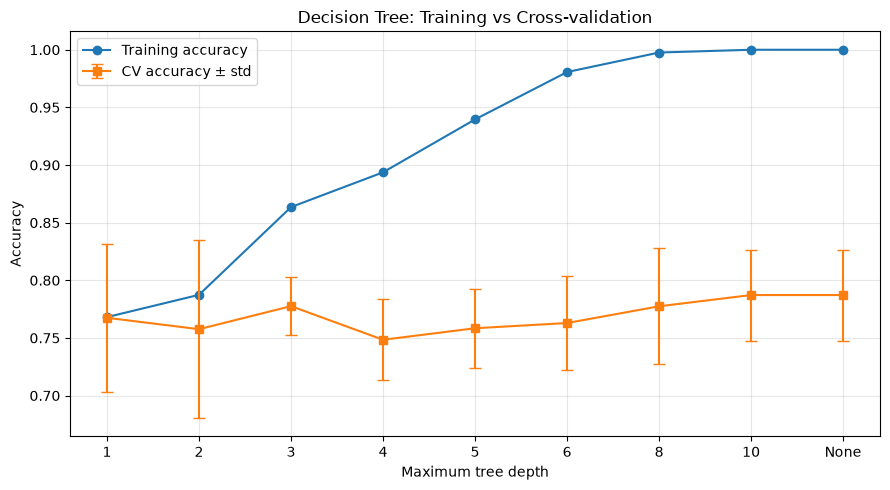

In [27]:
import matplotlib.pyplot as plt

x = np.arange(len(depth_table))
labels = depth_table["max_depth"].tolist()

plt.figure(figsize=(9, 5))

plt.plot(
    x, depth_table["train_accuracy"],
    marker="o", label="Training accuracy"
)

plt.errorbar(
    x,
    depth_table["cv_accuracy"],
    yerr=depth_table["cv_std"],
    marker="s",
    capsize=4,
    label="CV accuracy ± std"
)

plt.xticks(x, labels)
plt.xlabel("Maximum tree depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Training vs Cross-validation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Depth selection rule:** I will select the simplest tree whose mean cross-validation accuracy is within one standard error of the highest mean CV accuracy. I will compare the fold-to-fold standard deviation and the neighbouring depths before making the final choice. This avoids choosing a more complex tree for a small, potentially noisy improvement.


min_samples_leaf

In [28]:
leaf_sizes = [1, 2, 5, 10, 20, 40]
leaf_results = []

for leaf_size in leaf_sizes:
    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=None,
        min_samples_leaf=leaf_size,
        random_state=SEED
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )

    fitted = model.fit(X_train, y_train)

    leaf_results.append({
        "min_samples_leaf": leaf_size,
        "leaves": fitted.get_n_leaves(),
        "train_accuracy": scores["train_score"].mean(),
        "cv_accuracy": scores["test_score"].mean(),
        "cv_std": scores["test_score"].std()
    })

leaf_table = pd.DataFrame(leaf_results)
leaf_table.round(4)

,min_samples_leaf,leaves,train_accuracy,cv_accuracy,cv_std
0,1,32,1.0000,0.7872,0.0394
1,2,29,0.9589,0.7678,0.0464
2,5,19,0.8998,0.7777,0.0111
3,10,11,0.8623,0.7823,0.0322
4,20,7,0.7874,0.7576,0.0771
5,40,5,0.7681,0.7675,0.0644


In [29]:
from sklearn.metrics import accuracy_score

chosen_depth = 3  # Өз ережең бойынша таңдаған мәніңді жаз

final_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=chosen_depth,
    random_state=SEED
)

final_tree.fit(X_train, y_train)
test_pred = final_tree.predict(X_test)

p = accuracy_score(y_test, test_pred)
n = len(y_test)
standard_error = np.sqrt(p * (1 - p) / n)

print("Test accuracy:", round(p, 4))
print("Standard error:", round(standard_error, 4))

Test accuracy: 0.8333
Standard error: 0.0393


Part 4 — Decision Tree немесе Logistic Regression?

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Chosen tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=chosen_depth,
        random_state=SEED
    ),
    "Unlimited tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=None,
        random_state=SEED
    ),
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
}

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=("accuracy", "f1")
    )

    cv_results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_mean": scores["test_f1"].mean()
    })

cv_table = pd.DataFrame(cv_results)
cv_table.round(4)

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean
0,Chosen tree,0.7776,0.0253,0.7473
1,Unlimited tree,0.7872,0.0394,0.7636
2,Logistic regression,0.8021,0.0648,0.7790


In [31]:
tree_raw = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=chosen_depth,
    random_state=SEED
)
tree_raw.fit(X_train, y_train)
pred_raw = tree_raw.predict(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

tree_scaled = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=chosen_depth,
    random_state=SEED
)
tree_scaled.fit(X_train_scaled, y_train)
pred_scaled = tree_scaled.predict(X_test_scaled)

agreement = np.mean(pred_raw == pred_scaled)

print("Prediction agreement:", round(agreement, 4))

Prediction agreement: 1.0


In [32]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)

final_models = {
    "Chosen tree": DecisionTreeClassifier(
        criterion="entropy",
        max_depth=chosen_depth,
        random_state=SEED
    ),
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000)
    )
}

holdout_results = []

for name, model in final_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)

    se = np.sqrt(
        accuracy * (1 - accuracy) / len(y_test)
    )

    holdout_results.append({
        "model": name,
        "accuracy": accuracy,
        "standard_error": se,
        "f1": f1
    })

    print("\n", name)
    print("Accuracy:", round(accuracy, 4))
    print("Standard error:", round(se, 4))
    print("F1:", round(f1, 4))
    print("Confusion matrix:\n", cm)

holdout_table = pd.DataFrame(holdout_results)
holdout_table.round(4)


 Chosen tree
Accuracy: 0.8333
Standard error: 0.0393
F1: 0.7945
Confusion matrix:
 [[46  2]
 [13 29]]

 Logistic regression
Accuracy: 0.8889
Standard error: 0.0331
F1: 0.875
Confusion matrix:
 [[45  3]
 [ 7 35]]


,model,accuracy,standard_error,f1
0,Chosen tree,0.8333,0.0393,0.7945
1,Logistic regression,0.8889,0.0331,0.8750


**Conclusion**

The chosen decision tree achieved a mean cross-validation accuracy of [value] ± [std] and a mean F1 score of [value]. The unlimited-depth tree achieved [value] ± [std], while logistic regression achieved [value] ± [std] accuracy and an F1 score of [value]. On the hold-out test set, the chosen tree achieved an accuracy of [value] with a standard error of [value], compared with [value] and [value] for logistic regression. The fold-to-fold spread and test standard errors suggest that [describe whether the observed difference is clear or uncertain]. I would choose [model] because [reason supported by the measured results]. These results describe this teaching dataset and do not provide clinical evidence.


Part 5

In [33]:
from sklearn.tree import export_text

shallow = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=SEED
).fit(X_train, y_train)

print(export_text(
    shallow,
    feature_names=feature_names
))

ranked = sorted(
    zip(shallow.feature_importances_, feature_names),
    reverse=True
)

print([
    (name, round(float(importance), 3))
    for importance, name in ranked[:5]
])

|--- ca <= 0.50
|   |--- thal <= 6.50
|   |   |--- age <= 57.50
|   |   |   |--- class: 0
|   |   |--- age >  57.50
|   |   |   |--- class: 0
|   |--- thal >  6.50
|   |   |--- cp <= 3.50
|   |   |   |--- class: 0
|   |   |--- cp >  3.50
|   |   |   |--- class: 1
|--- ca >  0.50
|   |--- cp <= 3.50
|   |   |--- oldpeak <= 1.95
|   |   |   |--- class: 0
|   |   |--- oldpeak >  1.95
|   |   |   |--- class: 1
|   |--- cp >  3.50
|   |   |--- oldpeak <= 0.40
|   |   |   |--- class: 1
|   |   |--- oldpeak >  0.40
|   |   |   |--- class: 1

[('ca', 0.402), ('cp', 0.206), ('thal', 0.178), ('oldpeak', 0.122), ('age', 0.092)]


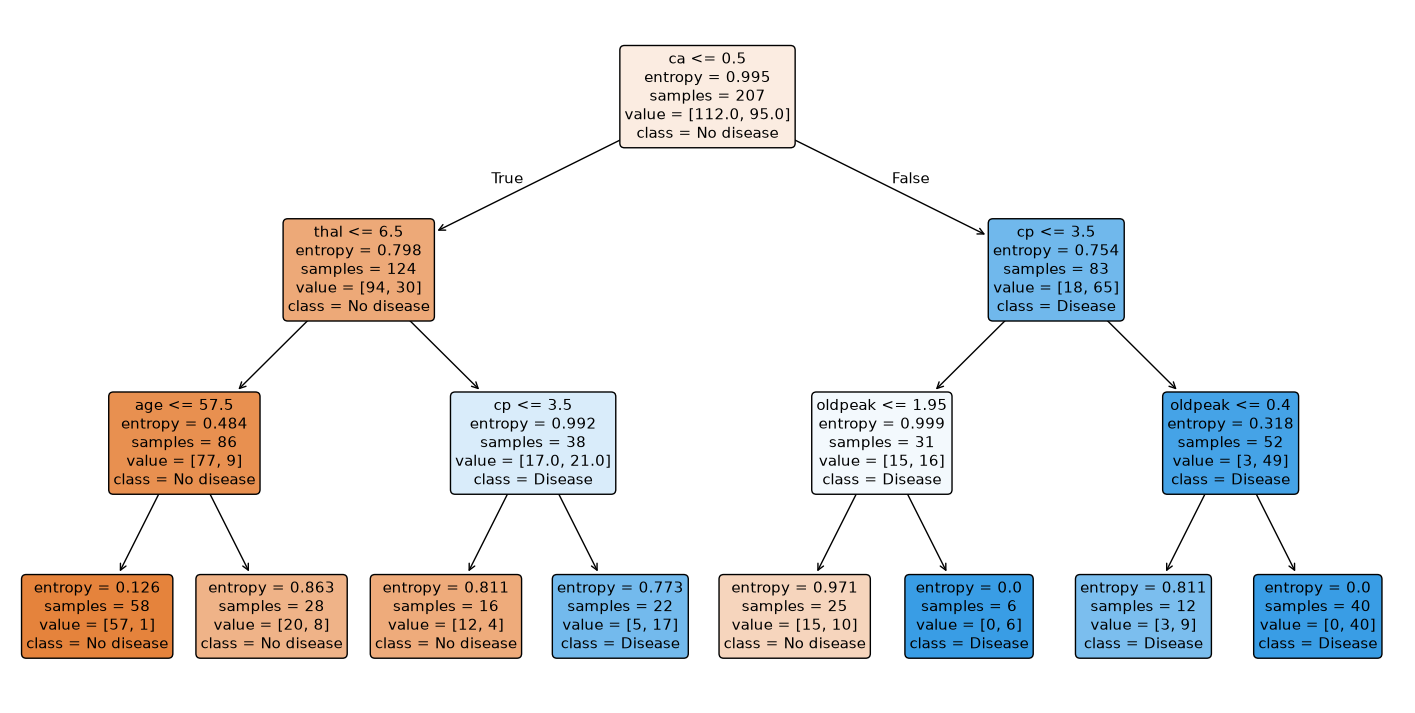

Node sample counts: [207 124  86  58  28  38  16  22  83  31  25   6  52  12  40]
Leaf nodes: [ 3  4  6  7 10 11 13 14]


In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 9))

plot_tree(
    shallow,
    feature_names=feature_names,
    class_names=["No disease", "Disease"],
    filled=True,
    rounded=True
)

plt.show()

print("Node sample counts:", shallow.tree_.n_node_samples)
print("Leaf nodes:", np.where(shallow.tree_.children_left == -1)[0])